In [2]:
# Spotify Business Analysis

## Business Problem

#The objective of this analysis is to identify the factors associated with track popularity and translate the findings into practical insights for music release and content strategy.

#Using Spotify track, artist, album, genre, and release information, the analysis will examine which characteristics are associated with stronger track popularity and how these patterns may support data informed decisions.

## Business Goal

#To identify measurable characteristics associated with higher track popularity and develop evidence based recommendations for artists, labels, and music strategy teams.

In [ ]:
## Research Objectives

### General Objective

To analyze the track, artist, genre, album, and release characteristics associated with Spotify track popularity and translate the findings into practical business insights.

### Specific Objectives

1. To determine the relationship between artist popularity and track popularity.

2. To examine whether artist follower count is associated with track popularity.

3. To compare the popularity of explicit and non explicit tracks.

4. To determine whether track duration is associated with track popularity.

5. To compare track popularity across album types and album sizes.

6. To identify genres associated with higher average track popularity.

7. To examine how track popularity differs across release periods.

8. To identify artists and tracks demonstrating strong popularity performance within the dataset.


## Research Questions

### RQ1
What is the relationship between artist popularity and track popularity?

### RQ2
What is the relationship between artist follower count and track popularity?

### RQ3
Is there a difference in track popularity between explicit and non explicit tracks?

### RQ4
How is track duration associated with track popularity?

### RQ5
Does track popularity differ across album types?

### RQ6
Does track popularity differ according to album size?

### RQ7
Which genres have the highest average track popularity?

### RQ8
How does track popularity vary across release periods?

### RQ9
Which artists demonstrate the highest average track popularity among artists with sufficient track representation?

### RQ10
Which tracks have the highest popularity scores in the dataset?


## Hypotheses

### H1
Higher artist popularity is associated with higher track popularity.

### H2
Artists with more followers tend to have tracks with higher popularity.

### H3
Explicit and non explicit tracks differ in their average track popularity.

### H4
Track duration is associated with track popularity.

### H5
Track popularity differs across album types.

### H6
Track popularity differs across different album sizes.

### H7
Average track popularity differs across music genres.

### H8
Track popularity differs across release periods.

### H9
Some artists demonstrate consistently higher track popularity than others when a minimum number of tracks is considered.

### H10
The highest performing tracks are concentrated among particular artists and recent releases.

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.home() / "Documents" / "spotify_project"
CLEAN_DATA = PROJECT_ROOT / "data" / "clean"
FIGURES = PROJECT_ROOT / "figures"

df = pd.read_csv(CLEAN_DATA / "spotify_final.csv")

print("Dataset shape:", df.shape)

Dataset shape: (8775, 16)


In [5]:
#RQ1: What is the relationship between artist popularity and track popularity?
rq1_correlation = df["artist_popularity"].corr(
    df["track_popularity"]
)

print("Correlation:", round(rq1_correlation, 2))

Correlation: 0.45


In [ ]:
#H: Higher artist popularity is associated with higher track popularity

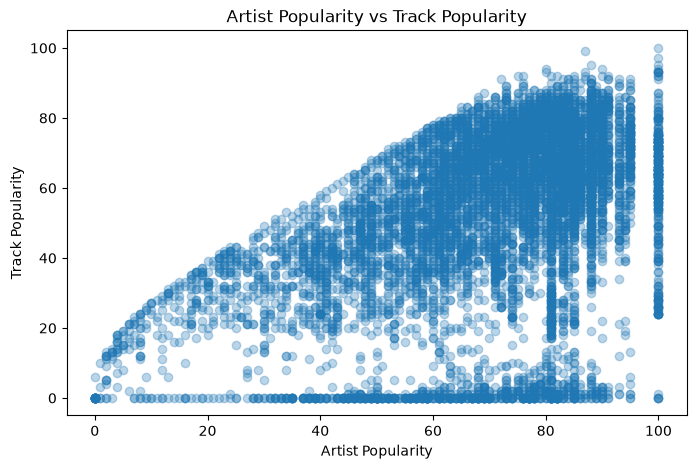

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["artist_popularity"],
    df["track_popularity"],
    alpha=0.3
)

plt.title("Artist Popularity vs Track Popularity")
plt.xlabel("Artist Popularity")
plt.ylabel("Track Popularity")

plt.show()

In [7]:
#Artist popularity is moderately associated with track popularity. Established artist visibility may provide an advantage in track performance, but other factors also contribute substantially to popularity.

In [8]:
#RQ2. What is the relationship between artist follower count and track popularity?
rq2_correlation = df["artist_followers"].corr(
    df["track_popularity"]
)

print("Correlation:", round(rq2_correlation, 2))

Correlation: 0.23


In [9]:
#H: Artists with more followers tend to have tracks with higher popularity.

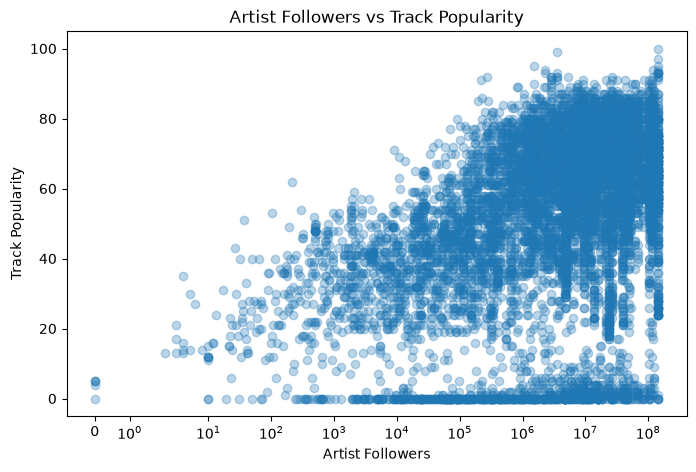

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["artist_followers"],
    df["track_popularity"],
    alpha=0.3
)

plt.xscale("symlog")

plt.title("Artist Followers vs Track Popularity")
plt.xlabel("Artist Followers")
plt.ylabel("Track Popularity")

plt.show()

In [11]:
#Artist follower count has a weak positive association with track popularity. Audience size may contribute to track visibility, but follower volume alone is not a strong indicator of track performance.

In [12]:
#RQ3. Is there a difference in track popularity between explicit and non explicit tracks?
rq3_result = df.groupby("explicit")["track_popularity"].agg(
    ["count", "mean", "median"]
).round(2)

rq3_result

,count,mean,median
explicit,,,
False,6584,50.49,55.0
True,2191,57.54,64.0


In [13]:
#Explicit and non explicit tracks differ in their average track popularity.

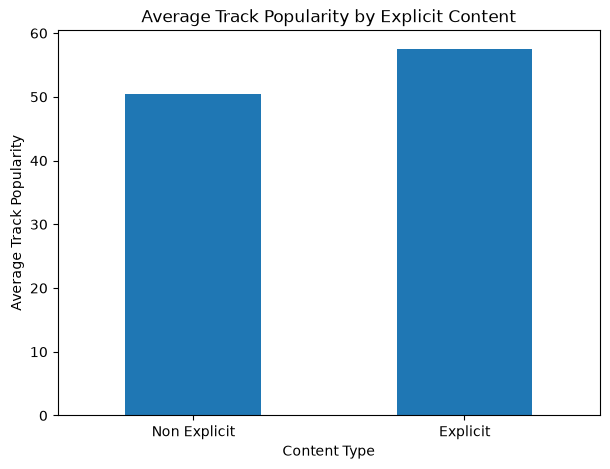

In [14]:
rq3_mean = df.groupby("explicit")["track_popularity"].mean()

rq3_mean.index = ["Non Explicit", "Explicit"]

rq3_mean.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Track Popularity by Explicit Content")
plt.xlabel("Content Type")
plt.ylabel("Average Track Popularity")
plt.xticks(rotation=0)

plt.show()

In [15]:
#Explicit tracks show higher popularity in this dataset, averaging 7.05 points above non explicit tracks. Explicit content may therefore be associated with stronger track performance, although the relationship should be considered alongside artist, genre, and release characteristics.

In [16]:
#RQ4> How is track duration associated with track popularity?
rq4_correlation = df["track_duration_min"].corr(
    df["track_popularity"]
)

print("Correlation:", round(rq4_correlation, 2))

Correlation: 0.1


In [20]:
#H: Track duration is associated with track popularity.


In [18]:
df["duration_group"] = pd.cut(
    df["track_duration_min"],
    bins=[0, 2, 4, 6, float("inf")],
    labels=["Short", "Standard", "Long", "Very Long"],
    right=False
)

In [19]:
rq4_groups = df.groupby(
    "duration_group",
    observed=True
)["track_popularity"].agg(
    ["count", "mean", "median"]
).round(2)

rq4_groups

,count,mean,median
duration_group,,,
Short,434,38.38,41.0
Standard,6146,52.61,59.0
Long,2026,54.53,60.0
Very Long,169,47.53,52.0


In [21]:
#Duration does not have a meaningful linear relationship with popularity, but popularity does vary across duration groups.

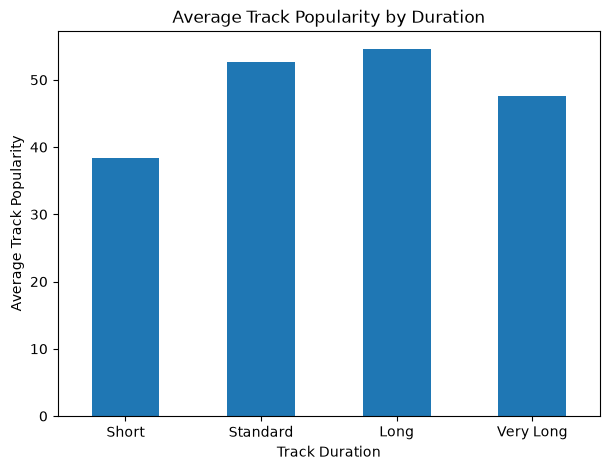

In [22]:
rq4_chart = rq4_groups["mean"]

rq4_chart.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Track Popularity by Duration")
plt.xlabel("Track Duration")
plt.ylabel("Average Track Popularity")
plt.xticks(rotation=0)

plt.show()

In [23]:
#Track length alone is not a strong predictor of popularity. However, tracks between 2 and 6 minutes show higher average popularity than very short or very long tracks in this dataset.

In [24]:
#RQ5. Does track popularity differ across album types?
rq5_result = df.groupby(
    "album_type"
)["track_popularity"].agg(
    ["count", "mean", "median"]
).round(2)

rq5_result

,count,mean,median
album_type,,,
album,6022,55.53,61.0
compilation,508,40.51,44.0
single,2245,46.11,51.0


In [25]:
#H: Track popularity differs across album types.

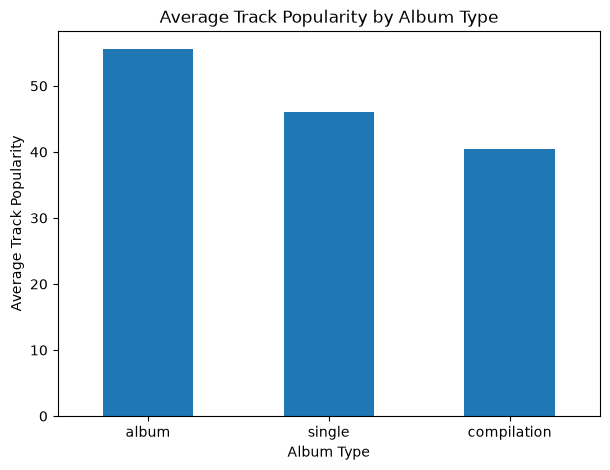

In [26]:
rq5_chart = rq5_result["mean"].sort_values(ascending=False)

rq5_chart.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Track Popularity by Album Type")
plt.xlabel("Album Type")
plt.ylabel("Average Track Popularity")
plt.xticks(rotation=0)

plt.show()

In [27]:
#Album tracks show the strongest popularity performance in this dataset, averaging about 9.4 points higher than singles and 15 points higher than compilation tracks. Release format appears to be associated with track popularity, although other artist and content characteristics may also contribute.

In [29]:
#RQ6. Does track popularity differ according to album size?
df["album_size_group"] = pd.cut(
    df["album_total_tracks"],
    bins=[0, 5, 12, 20, float("inf")],
    labels=["Small", "Medium", "Large", "Very Large"]
)

In [30]:
rq6_result = df.groupby(
    "album_size_group",
    observed=True
)["track_popularity"].agg(
    ["count", "mean", "median"]
).round(2)

rq6_result

,count,mean,median
album_size_group,,,
Small,2147,46.01,50.0
Medium,1961,56.34,63.0
Large,3251,56.15,62.0
Very Large,1416,47.09,49.0


In [31]:
#H: Track popularity differs across different album sizes.

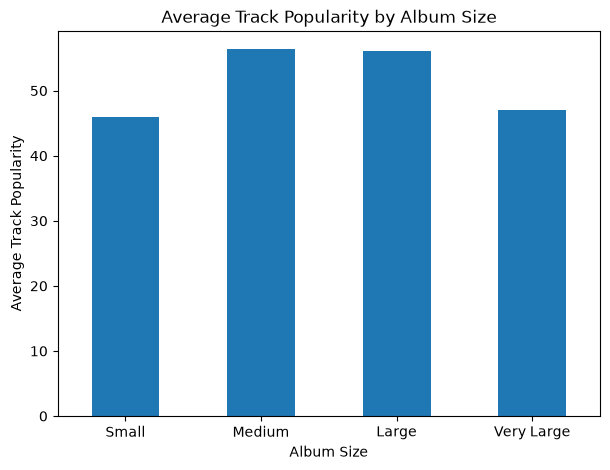

In [32]:
rq6_chart = rq6_result["mean"]

rq6_chart.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Track Popularity by Album Size")
plt.xlabel("Album Size")
plt.ylabel("Average Track Popularity")
plt.xticks(rotation=0)

plt.show()

In [33]:
#Tracks from releases containing 6 to 20 tracks show the strongest popularity performance in the dataset. Very small and very large releases have noticeably lower average popularity. This suggests that moderate release sizes are associated with stronger track performance, although album size should not be interpreted as a direct cause of popularity.

In [35]:
#RQ7. Which genres have the highest average track popularity
df_genres = df.dropna(subset=["artist_genres"]).copy()

df_genres["genre"] = df_genres["artist_genres"].str.split(", ")

df_genres = df_genres.explode("genre")

In [36]:
print("Genre records:", len(df_genres))
print("Unique genres:", df_genres["genre"].nunique())

Genre records: 7660
Unique genres: 423


In [37]:
rq7_result = df_genres.groupby("genre").agg(
    track_count=("track_id", "count"),
    average_popularity=("track_popularity", "mean")
)

rq7_result = rq7_result[
    rq7_result["track_count"] >= 30
].sort_values(
    "average_popularity",
    ascending=False
).head(10)

rq7_result.round(2)

,track_count,average_popularity
genre,,
trap latino,64,73.53
urbano latino,74,73.05
reggaeton,86,71.26
post-grunge,36,69.78
indie,54,68.74
gangster rap,33,68.09
latin,98,67.47
west coast hip hop,40,66.78
hyperpop,34,66.35


In [38]:
#Average track popularity varies substantially across genres. In particular, trap latino, urbano latino, and reggaeton have the highest average popularity among genres meeting our minimum sample requirement.

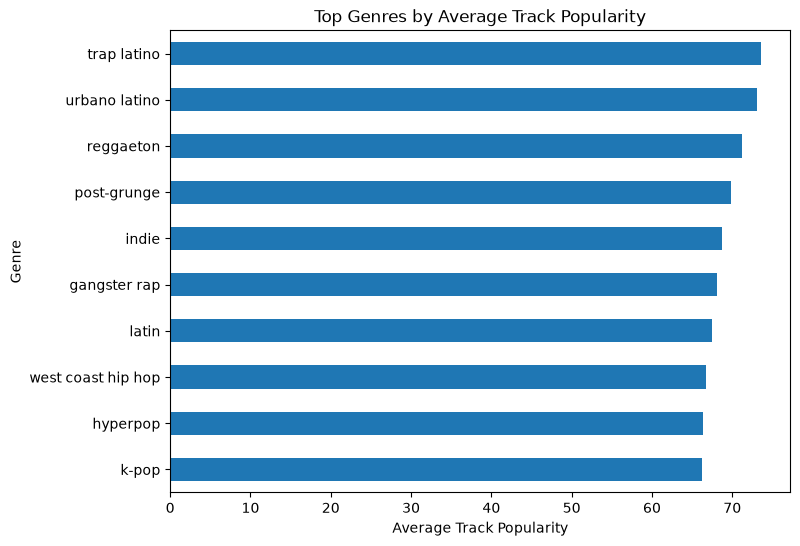

In [39]:
rq7_chart = (
    rq7_result["average_popularity"]
    .sort_values()
)

rq7_chart.plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Top Genres by Average Track Popularity")
plt.xlabel("Average Track Popularity")
plt.ylabel("Genre")

plt.show()

In [40]:
#Latin urban genres show particularly strong track popularity in this dataset. Trap latino leads with an average popularity of 73.53, followed by urbano latino at 73.05 and reggaeton at 71.26. This suggests that Latin urban music represents a strong performing segment within the analyzed catalog.

In [41]:
#RQ8. How does track popularity vary across release periods?
df["decade"] = (df["release_year"] // 10) * 10

rq8_result = df.groupby("decade")["track_popularity"].agg(
    ["count", "mean", "median"]
).round(2)

rq8_result

,count,mean,median
decade,,,
1950,7,53.57,58.0
1960,50,52.66,57.5
1970,80,63.70,72.0
1980,100,59.68,64.0
1990,406,51.05,58.0
2000,937,53.09,57.0
2010,3827,51.96,58.0
2020,3368,51.99,57.0


In [42]:
#H: The descriptive results support H8, since average popularity varies across release periods.

#However, we should not conclude that 1970s music is generally more popular on Spotify. The dataset is heavily concentrated in recent decades and may contain a selective sample of older tracks.

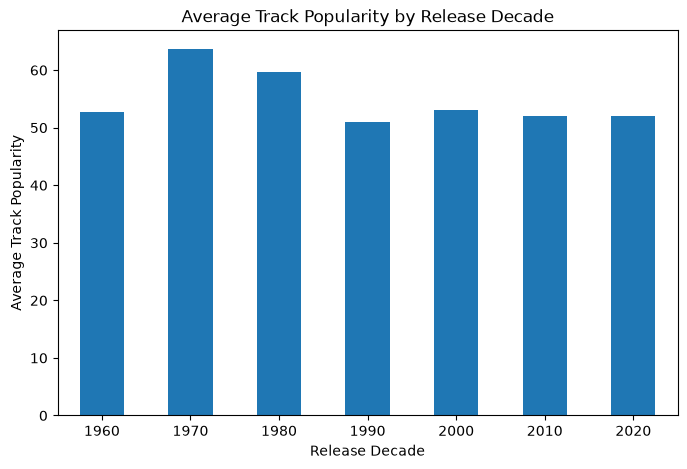

In [43]:
rq8_chart = rq8_result[
    rq8_result["count"] >= 30
]

rq8_chart["mean"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Track Popularity by Release Decade")
plt.xlabel("Release Decade")
plt.ylabel("Average Track Popularity")
plt.xticks(rotation=0)

plt.show()

In [44]:
#Popularity varies across release periods, with tracks from the 1970s and 1980s showing comparatively high average popularity in this dataset. However, older decades have substantially fewer observations, so these results should be interpreted cautiously.

In [45]:
#RQ9. Which artists demonstrate the highest average track popularity among artists with sufficient track representation?
rq9_result = df.groupby("artist_name").agg(
    track_count=("track_id", "count"),
    average_popularity=("track_popularity", "mean")
)

rq9_result = rq9_result[
    rq9_result["track_count"] >= 5
].sort_values(
    "average_popularity",
    ascending=False
).head(10)

rq9_result.round(2)

,track_count,average_popularity
artist_name,,
Alex Warren,5,83.40
Red Hot Chili Peppers,9,80.89
Arctic Monkeys,10,79.80
sombr,15,79.67
Benson Boone,7,79.00
Sabrina Carpenter,37,77.95
XXXTENTACION,8,77.75
Gracie Abrams,8,76.38
Tame Impala,13,75.00


In [46]:
#H: Some artists demonstrate substantially higher average track popularity than others when we require at least five tracks.

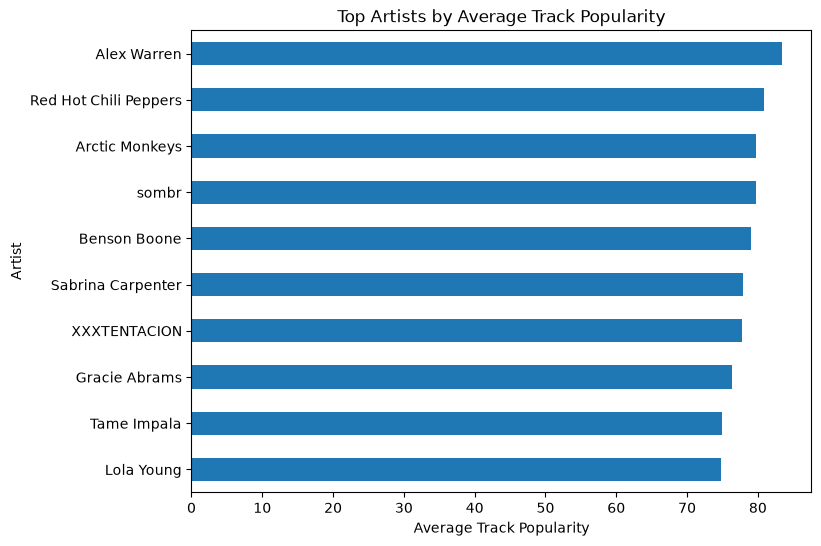

In [47]:
rq9_chart = (
    rq9_result["average_popularity"]
    .sort_values()
)

rq9_chart.plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Top Artists by Average Track Popularity")
plt.xlabel("Average Track Popularity")
plt.ylabel("Artist")

plt.show()

In [48]:
#Several artists demonstrate consistently strong track popularity. While Alex Warren records the highest average popularity, artists such as Sabrina Carpenter combine high average popularity with substantially greater track representation, indicating broader performance across the analyzed catalog.

In [49]:
#RQ10. Which tracks have the highest popularity scores in the dataset?
rq10_result = df[
    [
        "track_name",
        "artist_name",
        "track_popularity",
        "album_name",
        "release_year"
    ]
].sort_values(
    "track_popularity",
    ascending=False
).head(10)

rq10_result

,track_name,artist_name,track_popularity,album_name,release_year
7090,The Fate of Ophelia,Taylor Swift,100,The Life of a Showgirl,2025
4370,Golden,HUNTR/X,99,KPop Demon Hunters (Soundtrack from the Netfli...,2025
5494,Opalite,Taylor Swift,97,The Life of a Showgirl,2025
3634,Man I Need,Olivia Dean,95,Man I Need,2025
6448,Elizabeth Taylor,Taylor Swift,95,The Life of a Showgirl,2025
1390,BIRDS OF A FEATHER,Billie Eilish,94,HIT ME HARD AND SOFT,2024
3125,Soda Pop,Saja Boys,94,KPop Demon Hunters (Soundtrack from the Netfli...,2025
8656,Father Figure,Taylor Swift,94,The Life of a Showgirl,2025
2829,CANCELLED!,Taylor Swift,93,The Life of a Showgirl,2025
2556,Actually Romantic,Taylor Swift,93,The Life of a Showgirl,2025


In [50]:
#H: There is clear concentration in both artist representation and release recency among the Top 10 tracks in this dataset.

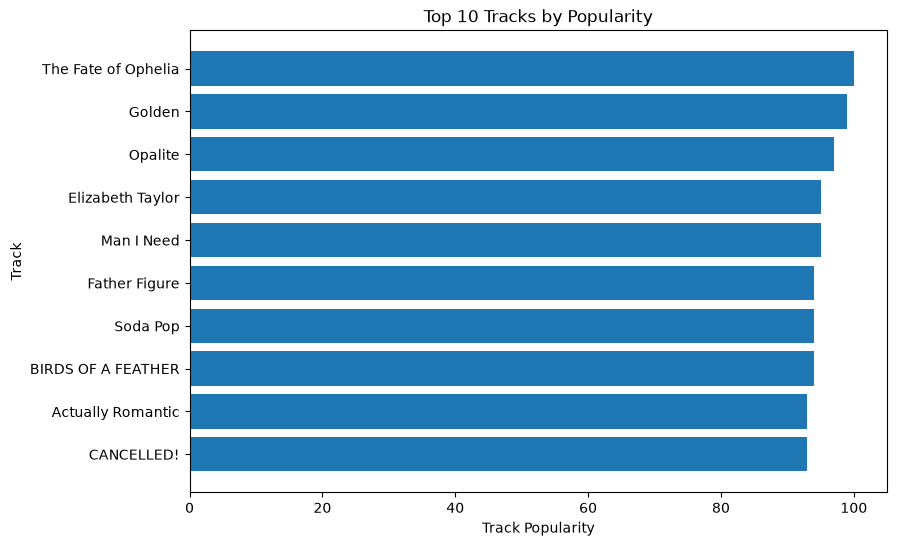

In [51]:
rq10_chart = rq10_result.sort_values(
    "track_popularity",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    rq10_chart["track_name"],
    rq10_chart["track_popularity"]
)

plt.title("Top 10 Tracks by Popularity")
plt.xlabel("Track Popularity")
plt.ylabel("Track")

plt.show()

In [52]:
#The highest popularity scores are concentrated among recent releases and a small group of artists. Nine of the Top 10 tracks were released in 2025, while Taylor Swift accounts for six positions. This suggests that current release momentum and established artist presence are prominent characteristics among the dataset's highest performing tracks.

In [53]:
## Hypothesis Summary

| RQ | Research Area | Key Result | Hypothesis Decision |
|---|---|---|---|
| RQ1 | Artist popularity | Correlation with track popularity = 0.45 | Supported descriptively |
| RQ2 | Artist followers | Correlation with track popularity = 0.23 | Weak descriptive support |
| RQ3 | Explicit content | Explicit tracks average 57.54 vs 50.49 for non explicit tracks | Supported descriptively |
| RQ4 | Track duration | Correlation = 0.10. Tracks between 2 and 6 minutes perform better by group | Weak descriptive support |
| RQ5 | Album type | Album tracks average 55.53, higher than singles and compilations | Supported descriptively |
| RQ6 | Album size | Releases with 6 to 20 tracks show the highest average popularity | Supported descriptively |
| RQ7 | Genre | Trap latino, urbano latino, and reggaeton lead among genres with at least 30 tracks | Supported descriptively |
| RQ8 | Release period | Popularity varies by decade, but older periods have smaller samples | Supported descriptively with caution |
| RQ9 | Artist performance | Several artists maintain high average popularity with at least 5 tracks | Supported descriptively |
| RQ10 | Top tracks | 9 of the Top 10 are from 2025 and 6 are Taylor Swift tracks | Supported descriptively |

SyntaxError: invalid syntax (879128337.py, line 3)

In [54]:
## Overall Business Findings

The analysis indicates that track popularity is associated with several artist, content, and release characteristics.

Artist popularity shows the strongest correlation with track popularity among the continuous variables examined. Artist follower count and track duration show considerably weaker relationships.

Explicit tracks show higher average popularity than non explicit tracks. Tracks released as part of albums also outperform singles and compilation tracks on average.

Tracks from releases containing 6 to 20 tracks perform better than tracks from very small or very large releases.

Genre analysis identifies strong performance among Latin urban genres, particularly trap latino, urbano latino, and reggaeton.

The highest performing tracks are heavily concentrated among recent releases and a small number of prominent artists.

These findings describe associations within the analyzed dataset and should not be interpreted as evidence that any single characteristic directly causes higher track popularity.

SyntaxError: invalid syntax (2075719214.py, line 3)